1. Import Libraries & Load Data

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (precision_recall_curve, auc, f1_score, precision_score, 
                            recall_score, confusion_matrix, classification_report, roc_auc_score)

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# For saving models
import joblib

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✓ Libraries imported")

✓ Libraries imported


2. Load Processed Data

In [ ]:
# Load Data
print("=" * 50)
print("LOADING PROCESSED DATA")
print("=" * 50)

# Load fraud data
X_fraud = joblib.load('../data/processed/X_fraud.pkl')
y_fraud = joblib.load('../data/processed/y_fraud.pkl')

# Load credit card data (if available, otherwise we'll focus on fraud data first)
try:
    X_credit = joblib.load('../data/processed/X_credit.pkl')
    y_credit = joblib.load('../data/processed/y_credit.pkl')
    credit_available = True
    print("✓ Credit card data loaded")
except:
    credit_available = False
    print("⚠️ Credit card data not found - will focus on fraud data first")

print(f"\nFraud Data Shape: {X_fraud.shape}")
print(f"Fraud Target Distribution:")
print(f"  Legitimate (0): {(y_fraud == 0).sum():,} ({((y_fraud == 0).sum()/len(y_fraud))*100:.2f}%)")
print(f"  Fraud (1): {(y_fraud == 1).sum():,} ({((y_fraud == 1).sum()/len(y_fraud))*100:.2f}%)")



LOADING PROCESSED DATA
⚠️ Credit card data not found - will focus on fraud data first

Fraud Data Shape: (129146, 39)
Fraud Target Distribution:
  Legitimate (0): 116,878 (90.50%)
  Fraud (1): 12,268 (9.50%)


3. Train-Test Split (Stratified)

In [3]:
# Train-Test Split
print("=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)

# Split fraud data
X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = train_test_split(
    X_fraud, y_fraud, test_size=0.2, stratify=y_fraud, random_state=42
)

print("Fraud Data Split:")
print(f"  Train: {X_fraud_train.shape} (Fraud rate: {y_fraud_train.mean():.4f})")
print(f"  Test: {X_fraud_test.shape} (Fraud rate: {y_fraud_test.mean():.4f})")

if credit_available:
    X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
        X_credit, y_credit, test_size=0.2, stratify=y_credit, random_state=42
    )
    print(f"\nCredit Data Split:")
    print(f"  Train: {X_credit_train.shape} (Fraud rate: {y_credit_train.mean():.6f})")
    print(f"  Test: {X_credit_test.shape} (Fraud rate: {y_credit_test.mean():.6f})")

TRAIN-TEST SPLIT
Fraud Data Split:
  Train: (103316, 39) (Fraud rate: 0.0950)
  Test: (25830, 39) (Fraud rate: 0.0950)


4. Apply SMOTE (Training Set Only)

In [4]:
# Apply SMOTE to Handle Class Imbalance
print("=" * 50)
print("APPLYING SMOTE")
print("=" * 50)

# Before SMOTE
print("Fraud Data - Before SMOTE:")
print(f"  Class 0: {(y_fraud_train == 0).sum():,}")
print(f"  Class 1: {(y_fraud_train == 1).sum():,}")
print(f"  Ratio: {(y_fraud_train == 0).sum() / (y_fraud_train == 1).sum():.1f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_fraud_train_resampled, y_fraud_train_resampled = smote.fit_resample(X_fraud_train, y_fraud_train)

# After SMOTE
print("\nFraud Data - After SMOTE:")
print(f"  Class 0: {(y_fraud_train_resampled == 0).sum():,}")
print(f"  Class 1: {(y_fraud_train_resampled == 1).sum():,}")
print(f"  Ratio: 1:1 (balanced)")

if credit_available:
    print("\n" + "-" * 30)
    print("Credit Data - Before SMOTE:")
    print(f"  Class 0: {(y_credit_train == 0).sum():,}")
    print(f"  Class 1: {(y_credit_train == 1).sum():,}")
    
    X_credit_train_resampled, y_credit_train_resampled = smote.fit_resample(X_credit_train, y_credit_train)
    
    print("\nCredit Data - After SMOTE:")
    print(f"  Class 0: {(y_credit_train_resampled == 0).sum():,}")
    print(f"  Class 1: {(y_credit_train_resampled == 1).sum():,}")

APPLYING SMOTE
Fraud Data - Before SMOTE:
  Class 0: 93,502
  Class 1: 9,814
  Ratio: 9.5:1

Fraud Data - After SMOTE:
  Class 0: 93,502
  Class 1: 93,502
  Ratio: 1:1 (balanced)


5. Evaluation Function

In [5]:
# Comprehensive Model Evaluation Function
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluate model with multiple metrics for imbalanced data"""
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Core metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # AUC-PR (best for imbalanced data)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    au_prc = auc(recall_curve, precision_curve)
    
    # AUC-ROC (for reference)
    au_roc = roc_auc_score(y_test, y_pred_proba)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Print results
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-PR: {au_prc:.4f}")
    print(f"AUC-ROC: {au_roc:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              Legit  Fraud")
    print(f"Actual Legit:  {cm[0,0]:6,}  {cm[0,1]:6,}")
    print(f"       Fraud:  {cm[1,0]:6,}  {cm[1,1]:6,}")
    
    return {
        'model_name': model_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'au_prc': au_prc,
        'au_roc': au_roc,
        'confusion_matrix': cm
    }

6. Baseline Model - Logistic Regression

In [6]:
# Logistic Regression Baseline
print("=" * 60)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("=" * 60)

# Train Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    C=1.0
)

lr_model.fit(X_fraud_train_resampled, y_fraud_train_resampled)

# Evaluate
lr_results = evaluate_model(lr_model, X_fraud_test, y_fraud_test, "Logistic Regression - Fraud Data")

# Save model
joblib.dump(lr_model, '../models/logistic_regression_fraud.pkl')
print("\n✓ Model saved to ../models/logistic_regression_fraud.pkl")

BASELINE MODEL: LOGISTIC REGRESSION

Logistic Regression - Fraud Data
Precision: 0.8801
Recall: 0.9723
F1-Score: 0.9239
AUC-PR: 0.9786
AUC-ROC: 0.9980

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  23,051     325
       Fraud:      68   2,386

✓ Model saved to ../models/logistic_regression_fraud.pkl


7. Random Forest Model

In [7]:
# Random Forest Model
print("=" * 60)
print("ENSEMBLE MODEL: RANDOM FOREST")
print("=" * 60)

# Train Random Forest with basic hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_fraud_train_resampled, y_fraud_train_resampled)

# Evaluate
rf_results = evaluate_model(rf_model, X_fraud_test, y_fraud_test, "Random Forest - Fraud Data")

# Save model
joblib.dump(rf_model, '../models/random_forest_fraud.pkl')
print("\n✓ Model saved to ../models/random_forest_fraud.pkl")

ENSEMBLE MODEL: RANDOM FOREST

Random Forest - Fraud Data
Precision: 0.8961
Recall: 0.9906
F1-Score: 0.9410
AUC-PR: 0.9915
AUC-ROC: 0.9991

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  23,094     282
       Fraud:      23   2,431

✓ Model saved to ../models/random_forest_fraud.pkl


8. XGBoost Model (Best for Fraud Detection)

In [8]:
# XGBoost Model
print("=" * 60)
print("GRADIENT BOOSTING: XGBOOST")
print("=" * 60)

# Calculate scale_pos_weight (ratio of negative to positive)
scale_pos_weight = len(y_fraud_train[y_fraud_train==0]) / len(y_fraud_train[y_fraud_train==1])

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_fraud_train_resampled, y_fraud_train_resampled)

# Evaluate
xgb_results = evaluate_model(xgb_model, X_fraud_test, y_fraud_test, "XGBoost - Fraud Data")

# Save model
joblib.dump(xgb_model, '../models/xgboost_fraud.pkl')
print("\n✓ Model saved to ../models/xgboost_fraud.pkl")

GRADIENT BOOSTING: XGBOOST

XGBoost - Fraud Data
Precision: 0.8923
Recall: 0.9963
F1-Score: 0.9415
AUC-PR: 0.9940
AUC-ROC: 0.9993

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  23,081     295
       Fraud:       9   2,445

✓ Model saved to ../models/xgboost_fraud.pkl


9. Hyperparameter Tuning for XGBoost

In [9]:
# Hyperparameter Tuning (Optional - takes time)
print("=" * 60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("=" * 60)

# Use a smaller sample for faster tuning
tuning_sample_size = min(50000, len(X_fraud_train_resampled))
X_sample = X_fraud_train_resampled[:tuning_sample_size]
y_sample = y_fraud_train_resampled[:tuning_sample_size]

print(f"Using {tuning_sample_size} samples for tuning")

# Parameter grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8]
}

# Grid search
xgb_tune = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

grid_search = GridSearchCV(
    xgb_tune, 
    param_grid, 
    scoring='f1', 
    cv=3, 
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_sample, y_sample)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_xgb = XGBClassifier(
    **grid_search.best_params_,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

best_xgb.fit(X_fraud_train_resampled, y_fraud_train_resampled)

# Evaluate tuned model
best_xgb_results = evaluate_model(best_xgb, X_fraud_test, y_fraud_test, "XGBoost (Tuned) - Fraud Data")

# Save tuned model
joblib.dump(best_xgb, '../models/xgboost_fraud_tuned.pkl')
print("\n✓ Tuned model saved to ../models/xgboost_fraud_tuned.pkl")

HYPERPARAMETER TUNING - XGBOOST
Using 50000 samples for tuning
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 150, 'subsample': 0.8}
Best F1 score: 0.9464

XGBoost (Tuned) - Fraud Data
Precision: 0.9044
Recall: 0.9866
F1-Score: 0.9437
AUC-PR: 0.9941
AUC-ROC: 0.9994

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  23,120     256
       Fraud:      33   2,421

✓ Tuned model saved to ../models/xgboost_fraud_tuned.pkl


10. Cross-Validation

In [10]:
# Cross-Validation for Best Model
print("=" * 60)
print("CROSS-VALIDATION (5-Fold Stratified)")
print("=" * 60)

# Use the best model (tuned XGBoost or regular)
best_model = best_xgb if 'best_xgb' in locals() else xgb_model

# Perform 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
f1_scores = cross_val_score(best_model, X_fraud_train_resampled, y_fraud_train_resampled, 
                           cv=skf, scoring='f1')
precision_scores = cross_val_score(best_model, X_fraud_train_resampled, y_fraud_train_resampled, 
                                  cv=skf, scoring='precision')
recall_scores = cross_val_score(best_model, X_fraud_train_resampled, y_fraud_train_resampled, 
                               cv=skf, scoring='recall')

print("\nCross-Validation Results (5-fold):")
print(f"  F1 Score:      {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
print(f"  Precision:     {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")
print(f"  Recall:        {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")

CROSS-VALIDATION (5-Fold Stratified)

Cross-Validation Results (5-fold):
  F1 Score:      0.9940 (+/- 0.0003)
  Precision:     0.9895 (+/- 0.0006)
  Recall:        0.9986 (+/- 0.0002)


11. Model Comparision

MODEL COMPARISON
✓ Logistic Regression results added
✓ Random Forest results added
✓ XGBoost results added
✓ Tuned XGBoost results added

MODEL PERFORMANCE COMPARISON
                           Model  Precision   Recall  F1-Score   AUC-PR  AUC-ROC
Logistic Regression - Fraud Data   0.880118 0.972290  0.923911 0.978649 0.998004
      Random Forest - Fraud Data   0.896056 0.990628  0.940972 0.991465 0.999135
            XGBoost - Fraud Data   0.892336 0.996333  0.941471 0.993987 0.999341
    XGBoost (Tuned) - Fraud Data   0.904371 0.986553  0.943676 0.994091 0.999353

🏆 BEST MODEL: XGBoost (Tuned) - Fraud Data
   F1-Score: 0.9437


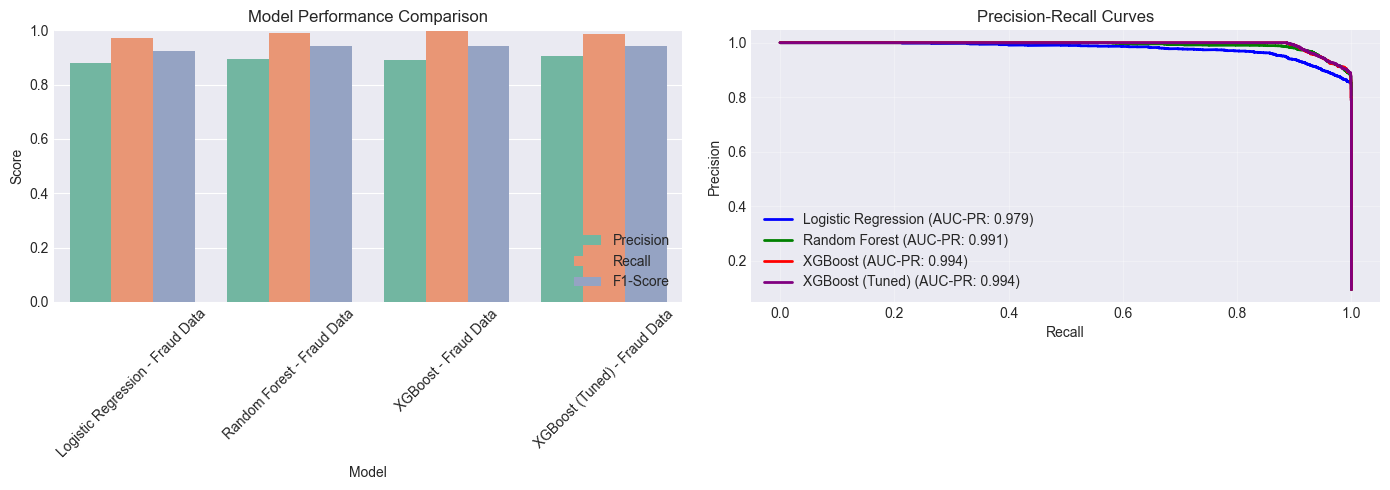


✓ Comparison chart saved to ../data/processed/model_comparison.png


In [12]:
# Model Comparison Table and Visualization
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Collect results (make sure these variables exist)
results = []

# Add results if they exist
try:
    results.append(lr_results)
    print("✓ Logistic Regression results added")
except NameError:
    print("⚠️ Logistic Regression results not found")

try:
    results.append(rf_results)
    print("✓ Random Forest results added")
except NameError:
    print("⚠️ Random Forest results not found")

try:
    results.append(xgb_results)
    print("✓ XGBoost results added")
except NameError:
    print("⚠️ XGBoost results not found")

try:
    if 'best_xgb_results' in locals():
        results.append(best_xgb_results)
        print("✓ Tuned XGBoost results added")
except NameError:
    print("⚠️ Tuned XGBoost results not found")

# Check if we have results
if len(results) == 0:
    print("\n❌ No model results found! Run Cells 6, 7, and 8 first.")
else:
    # Create comparison dataframe
    comparison_data = []
    for r in results:
        comparison_data.append({
            'Model': r['model_name'],
            'Precision': r['precision'],
            'Recall': r['recall'],
            'F1-Score': r['f1'],
            'AUC-PR': r['au_prc'],
            'AUC-ROC': r['au_roc']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("\n" + "=" * 60)
    print("MODEL PERFORMANCE COMPARISON")
    print("=" * 60)
    print(comparison_df.to_string(index=False))
    
    # Highlight best model
    best_f1_idx = comparison_df['F1-Score'].idxmax()
    print(f"\n🏆 BEST MODEL: {comparison_df.loc[best_f1_idx, 'Model']}")
    print(f"   F1-Score: {comparison_df.loc[best_f1_idx, 'F1-Score']:.4f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Bar plot comparison
    comparison_melted = comparison_df.melt(
        id_vars=['Model'], 
        value_vars=['Precision', 'Recall', 'F1-Score'],
        var_name='Metric',
        value_name='Score'
    )
    
    sns.barplot(
        data=comparison_melted, 
        x='Model', 
        y='Score', 
        hue='Metric',
        ax=axes[0]
    )
    axes[0].set_title('Model Performance Comparison', fontsize=12)
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('Score')
    axes[0].legend(loc='lower right')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Precision-Recall Curves
    colors = ['blue', 'green', 'red', 'purple', 'orange'][:len(results)]
    
    for i, r in enumerate(results):
        # Get the model object based on name
        model_name = r['model_name'].split('-')[0].strip().lower()
        
        if 'logistic' in model_name:
            model_obj = lr_model
        elif 'random' in model_name:
            model_obj = rf_model
        elif 'xgboost' in model_name:
            if 'tuned' in model_name.lower():
                model_obj = best_xgb if 'best_xgb' in locals() else xgb_model
            else:
                model_obj = xgb_model
        else:
            continue
        
        # Get predictions
        y_pred_proba = model_obj.predict_proba(X_fraud_test)[:, 1]
        precision_curve, recall_curve, _ = precision_recall_curve(y_fraud_test, y_pred_proba)
        
        axes[1].plot(
            recall_curve, precision_curve, 
            label=f"{r['model_name'].split('-')[0].strip()} (AUC-PR: {r['au_prc']:.3f})", 
            color=colors[i], 
            linewidth=2
        )
    
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curves', fontsize=12)
    axes[1].legend(loc='lower left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../data/processed/model_comparison.png', dpi=100)
    plt.show()
    
    print("\n✓ Comparison chart saved to ../data/processed/model_comparison.png")

In [13]:
# Check available models
print("Available models:")
print(f"  lr_model: {'lr_model' in dir()}")
print(f"  rf_model: {'rf_model' in dir()}")
print(f"  xgb_model: {'xgb_model' in dir()}")
print(f"  best_xgb: {'best_xgb' in dir()}")

Available models:
  lr_model: True
  rf_model: True
  xgb_model: True
  best_xgb: True


12. Feature Importance (Random Forest & XGBoost)

FEATURE IMPORTANCE


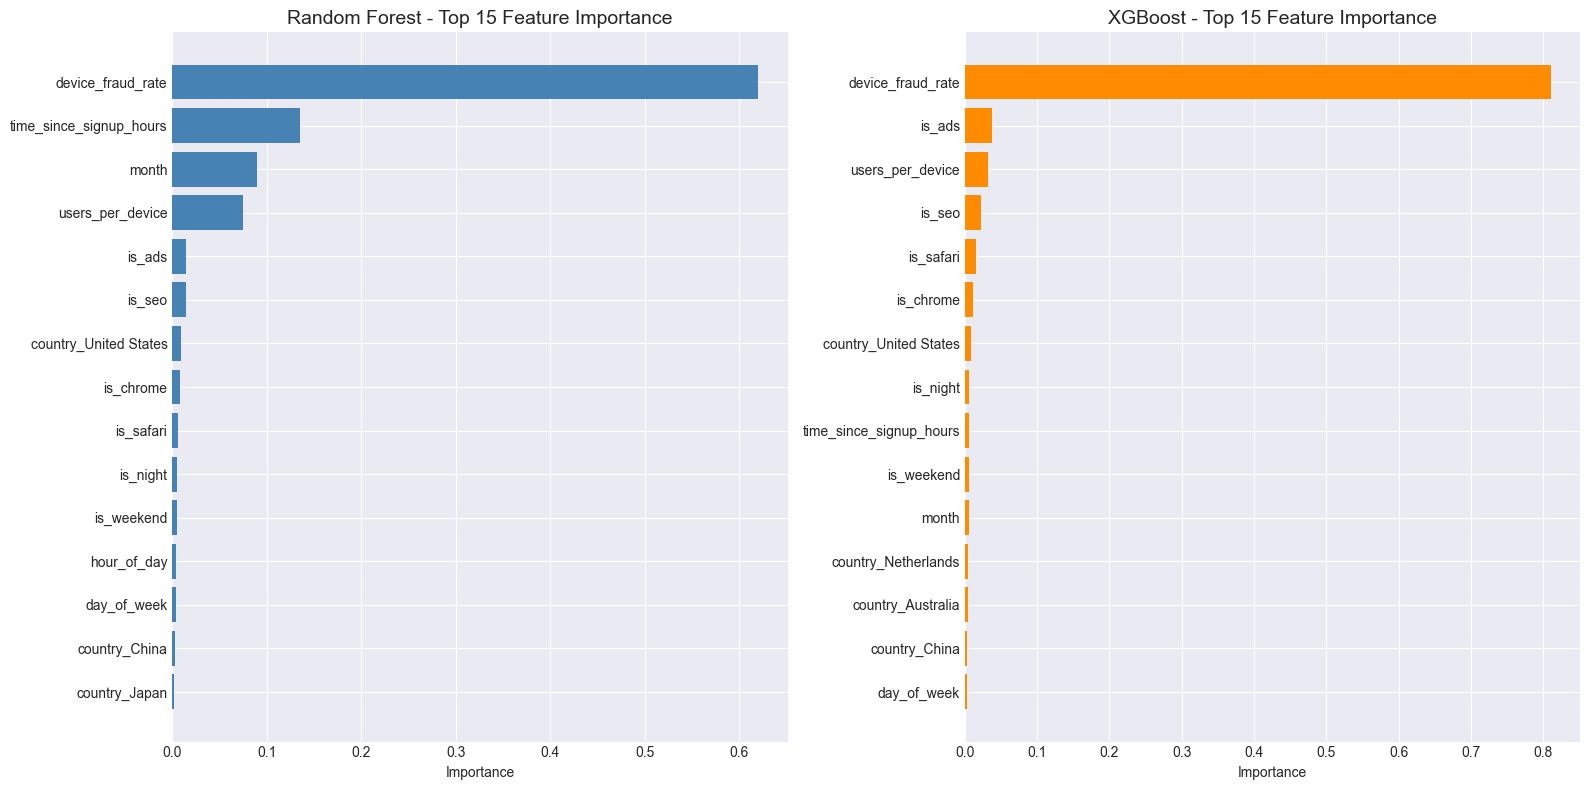


Top 10 Features - Random Forest:
                feature  importance
      device_fraud_rate    0.620411
time_since_signup_hours    0.134676
                  month    0.090051
       users_per_device    0.074801
                 is_ads    0.014957
                 is_seo    0.014808
  country_United States    0.009406
              is_chrome    0.008300
              is_safari    0.005609
               is_night    0.005287

Top 10 Features - XGBoost:
                feature  importance
      device_fraud_rate    0.810430
                 is_ads    0.036884
       users_per_device    0.031887
                 is_seo    0.022820
              is_safari    0.015839
              is_chrome    0.011857
  country_United States    0.008740
               is_night    0.006038
time_since_signup_hours    0.005595
             is_weekend    0.005283


In [14]:
# Feature Importance Analysis
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Get feature names
feature_names = X_fraud.columns.tolist()

# Random Forest Importance
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# XGBoost Importance
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest Top 15
top_rf = rf_importance.head(15)
axes[0].barh(top_rf['feature'], top_rf['importance'], color='steelblue')
axes[0].set_title('Random Forest - Top 15 Feature Importance', fontsize=14)
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# XGBoost Top 15
top_xgb = xgb_importance.head(15)
axes[1].barh(top_xgb['feature'], top_xgb['importance'], color='darkorange')
axes[1].set_title('XGBoost - Top 15 Feature Importance', fontsize=14)
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=100)
plt.show()

print("\nTop 10 Features - Random Forest:")
print(top_rf[['feature', 'importance']].head(10).to_string(index=False))

print("\nTop 10 Features - XGBoost:")
print(top_xgb[['feature', 'importance']].head(10).to_string(index=False))

13. Select Best Model & Save 

In [15]:
# Select and Save Best Model
print("=" * 60)
print("SELECTING BEST MODEL")
print("=" * 60)

# Compare F1 scores
best_f1 = max([r['f1'] for r in results])
best_model_name = [r['model_name'] for r in results if r['f1'] == best_f1][0]

print(f"Best Model: {best_model_name}")
print(f"Best F1-Score: {best_f1:.4f}")

# Save best model reference
if 'XGBoost' in best_model_name:
    if 'best_xgb' in locals() and 'Tuned' in best_model_name:
        final_model = best_xgb
        model_name = 'xgboost_tuned'
    else:
        final_model = xgb_model
        model_name = 'xgboost'
elif 'Random Forest' in best_model_name:
    final_model = rf_model
    model_name = 'random_forest'
else:
    final_model = lr_model
    model_name = 'logistic_regression'

# Save final model
joblib.dump(final_model, f'../models/best_model_{model_name}.pkl')
print(f"\n✓ Final model saved to ../models/best_model_{model_name}.pkl")

# Save feature names for SHAP analysis
joblib.dump(feature_names, '../models/feature_names.pkl')
print("✓ Feature names saved for SHAP analysis")

# Summary
print("\n" + "=" * 60)
print("MODELING COMPLETE!")
print("=" * 60)
print(f"Final Model: {model_name}")
print(f"Test Set Performance:")
print(f"  - F1-Score: {best_f1:.4f}")
print(f"  - Precision: {[r['precision'] for r in results if r['f1'] == best_f1][0]:.4f}")
print(f"  - Recall: {[r['recall'] for r in results if r['f1'] == best_f1][0]:.4f}")

SELECTING BEST MODEL
Best Model: XGBoost (Tuned) - Fraud Data
Best F1-Score: 0.9437

✓ Final model saved to ../models/best_model_xgboost_tuned.pkl
✓ Feature names saved for SHAP analysis

MODELING COMPLETE!
Final Model: xgboost_tuned
Test Set Performance:
  - F1-Score: 0.9437
  - Precision: 0.9044
  - Recall: 0.9866


14. Quick Test on Sample Predictions

In [17]:
# Sample Predictions Analysis (FIXED)
print("=" * 60)
print("SAMPLE PREDICTION ANALYSIS")
print("=" * 60)

# Get predictions on test set
y_pred = final_model.predict(X_fraud_test)
y_pred_proba = final_model.predict_proba(X_fraud_test)[:, 1]

# Create results dataframe
results_df = X_fraud_test.copy()
results_df['true_label'] = y_fraud_test.values
results_df['predicted_label'] = y_pred
results_df['fraud_probability'] = y_pred_proba

# Get feature names as list
if isinstance(feature_names, list):
    feature_list = feature_names
else:
    feature_list = feature_names.tolist() if hasattr(feature_names, 'tolist') else list(feature_names)

# Show examples
print("\n🔴 HIGHEST FRAUD PROBABILITY (Top 10 Legitimate Transactions flagged as Fraud)")
false_positives = results_df[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 1)]
if len(false_positives) > 0:
    display_cols = ['fraud_probability'] + feature_list[:5]
    print(false_positives.nlargest(10, 'fraud_probability')[display_cols].to_string())
else:
    print("  No false positives found")

print("\n🟢 MISSED FRAUD (Top 10 Fraudulent transactions missed)")
false_negatives = results_df[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 0)]
if len(false_negatives) > 0:
    display_cols = ['fraud_probability'] + feature_list[:5]
    print(false_negatives.nlargest(10, 'fraud_probability')[display_cols].to_string())
else:
    print("  No false negatives found")

print("\n✅ CORRECT FRAUD DETECTION (Top 10)")
true_positives = results_df[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 1)]
if len(true_positives) > 0:
    display_cols = ['fraud_probability'] + feature_list[:5]
    print(true_positives.nlargest(10, 'fraud_probability')[display_cols].to_string())
else:
    print("  No true positives found")

# Summary statistics
print("\n" + "=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Total test samples: {len(results_df):,}")
print(f"True Positives (correctly caught fraud): {len(true_positives):,}")
print(f"False Positives (legitimate flagged as fraud): {len(false_positives):,}")
print(f"False Negatives (missed fraud): {len(false_negatives):,}")
print(f"True Negatives (correctly passed): {len(results_df[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 0)]):,}")

SAMPLE PREDICTION ANALYSIS

🔴 HIGHEST FRAUD PROBABILITY (Top 10 Legitimate Transactions flagged as Fraud)
       fraud_probability  purchase_value  age  time_since_signup_hours  transactions_last_hour  transactions_last_24h
73327           0.994610              62   27               965.710556                       0                      0
49694           0.993850              30   32               185.100000                       0                      0
56701           0.993081              27   38              1989.180556                       0                      0
58213           0.992465              46   24              2311.376667                       0                      0
17974           0.991419              34   53              2782.146944                       0                      0
77740           0.990044              39   34              2154.378333                       0                      0
5029            0.988400              30   35              2103.5213